In [1]:
import os

dataset_path = '/kaggle/input'

In [ ]:
import os


os.environ['KAGGLE_API_TOKEN'] = "KGAT_c1b3be8ddc42844039565500f9122ec4"

!kaggle datasets download -d danialqashqai/mfnet-dataset

!unzip -q mfnet-dataset.zip -d /content/

print("Done!")

Dataset URL: https://www.kaggle.com/datasets/danialqashqai/mfnet-dataset
License(s): MIT
100% 715M/715M [00:06<00:00, 110MB/s]

✅ Dataset scaricato ed estratto con successo su Colab!


In [ ]:
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from google.colab import drive

drive.mount('/content/drive')
percorso_pesi_rgb = "/content/drive/MyDrive/best_rgb.pth"
percorso_pesi_ir = "/content/drive/MyDrive/best_ir.pth"

Mounted at /content/drive


In [2]:
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

class MFNetDataset(Dataset):
    def __init__(self, base_path, transform=None, mode='train', drop_prob=0):

        # Directories for images and labels
        self.img_dir = os.path.join(base_path, "images")
        self.mask_dir = os.path.join(base_path, "labels")

        # Find common files between images and masks
        img_names = {os.path.splitext(f)[0] for f in os.listdir(self.img_dir)}
        mask_names = {os.path.splitext(f)[0] for f in os.listdir(self.mask_dir)}

        self.common_names = sorted(list(img_names.intersection(mask_names)))

        print(f"Dataset initialized: {len(self.common_names)} 4-channel images found.")
        self.transform = transform

        self.mode = mode             # 'train' or 'test'
        self.drop_prob = drop_prob

    def __len__(self):
        return len(self.common_names)

    def __getitem__(self, idx):
        base_name = self.common_names[idx]

        img_path = os.path.join(self.img_dir, base_name + ".png")
        mask_path = os.path.join(self.mask_dir, base_name + ".png")

        # Open the raw image keeping all 4 channels (RGBA)
        img_rgba = Image.open(img_path)

        # Extract Visual image (first 3 channels: RGB)
        img_visual = img_rgba.convert('RGB')

        # Extract Thermal image (Alpha channel) and convert to 3-channel RGB
        # to match the 3 in_channels expected by the U-Net
        img_thermal = img_rgba.getchannel('A').convert('RGB')

        # Load and prepare the mask
        img_mask = Image.open(mask_path).convert('L')
        mask_np = np.array(img_mask)
        tensor_mask = torch.as_tensor(mask_np, dtype=torch.long)

        # Apply transformations
        if self.transform:
            tensor_thermal = self.transform(img_thermal)
            tensor_visual = self.transform(img_visual)
        else:
            tensor_thermal = img_thermal
            tensor_visual = img_visual

        if self.mode == 'train':
            rand_val = random.random() # Generates a number between 0.0 and 1.0

            # 1. Drop Thermal, Keep RGB
            if rand_val < self.drop_prob:
                # Replace the entire thermal tensor with zeros
                tensor_thermal = torch.zeros_like(tensor_thermal)

            # 2. Drop RGB, Keep Thermal
            elif rand_val < (2 * self.drop_prob):
                # Replace the entire visual tensor with zeros
                tensor_visual = torch.zeros_like(tensor_visual)

        return tensor_thermal, tensor_visual, tensor_mask

In [4]:
torch.cuda.empty_cache()

Dataset initialized: 1569 4-channel images found.


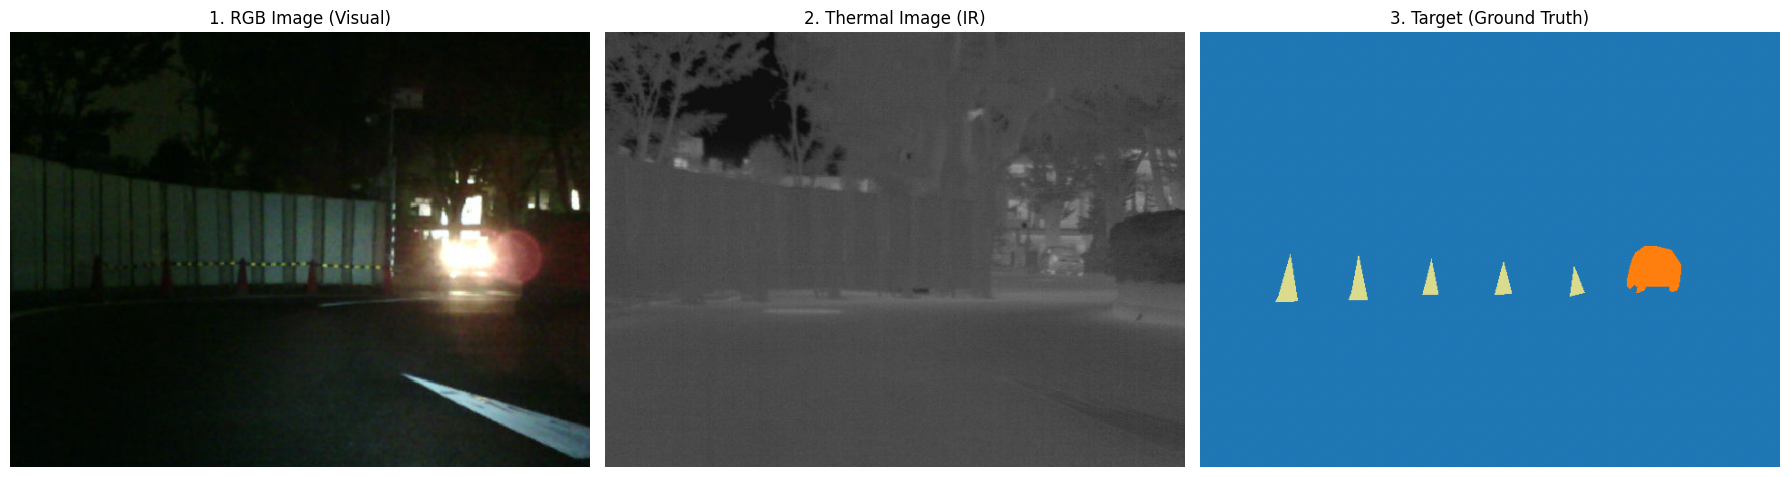

In [7]:
import matplotlib.pyplot as plt
import random
from torchvision import transforms

# Initialize the dataset
transform = transforms.ToTensor()
dataset_training = MFNetDataset(
    base_path="/kaggle/input/datasets/danialqashqai/mfnet-dataset/MFNet-dataset/ir_seg_dataset",
    transform=transform
)

# Select a random image from the dataset
random_index = random.randint(0, len(dataset_training) - 1)
img_thermal, img_visual, true_mask = dataset_training[random_index]

# Prepare images for Matplotlib
img_t_plot = img_thermal.permute(1, 2, 0).numpy()
img_v_plot = img_visual.permute(1, 2, 0).numpy()
mask_plot = true_mask.numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# COLUMN 1: Visual Image (RGB)
axes[0].imshow(img_v_plot)
axes[0].set_title("1. RGB Image (Visual)")
axes[0].axis('off')

# COLUMN 2: Thermal Image
axes[1].imshow(img_t_plot)
axes[1].set_title("2. Thermal Image (IR)")
axes[1].axis('off')

# COLUMN 3: Target Mask
axes[2].imshow(mask_plot, cmap='tab20', vmin=0, vmax=8)
axes[2].set_title("3. Target (Ground Truth)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [5]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.conv_block(x)
        return x

class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=9):
        super(UNet, self).__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)
        self.bottleneck = DoubleConv(512, 1024)
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up_conv1 = DoubleConv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_conv2 = DoubleConv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_conv3 = DoubleConv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_conv4 = DoubleConv(128, 64)
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.down1(x)
        p1 = self.pool(x1)
        x2 = self.down2(p1)
        p2 = self.pool(x2)
        x3 = self.down3(p2)
        p3 = self.pool(x3)
        x4 = self.down4(p3)
        p4 = self.pool(x4)
        b = self.bottleneck(p4)
        u1 = self.up1(b)
        concat1 = torch.cat([x4, u1], dim=1)
        d1 = self.up_conv1(concat1)
        u2 = self.up2(d1)
        concat2 = torch.cat([x3, u2], dim=1)
        d2 = self.up_conv2(concat2)
        u3 = self.up3(d2)
        concat3 = torch.cat([x2, u3], dim=1)
        d3 = self.up_conv3(concat3)
        u4 = self.up4(d3)
        concat4 = torch.cat([x1, u4], dim=1)
        d4 = self.up_conv4(concat4)
        out = self.final_conv(d4)
        return out

class DualNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=9):
        super(DualNet, self).__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.down1_rgb = DoubleConv(in_channels, 64)
        self.down2_rgb = DoubleConv(64, 128)
        self.down3_rgb = DoubleConv(128, 256)
        self.down4_rgb = DoubleConv(256, 512)
        self.down1_thermal = DoubleConv(in_channels, 64)
        self.down2_thermal = DoubleConv(64, 128)
        self.down3_thermal = DoubleConv(128, 256)
        self.down4_thermal = DoubleConv(256, 512)
        self.bottleneck = DoubleConv(1024, 1024)
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up_conv1 = DoubleConv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_conv2 = DoubleConv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_conv3 = DoubleConv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_conv4 = DoubleConv(128, 64)
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x_rgb, x_thermal):
        x1_rgb = self.down1_rgb(x_rgb)
        p1_rgb = self.pool(x1_rgb)
        x2_rgb = self.down2_rgb(p1_rgb)
        p2_rgb = self.pool(x2_rgb)
        x3_rgb = self.down3_rgb(p2_rgb)
        p3_rgb = self.pool(x3_rgb)
        x4_rgb = self.down4_rgb(p3_rgb)
        p4_rgb = self.pool(x4_rgb)
        x1_thermal = self.down1_thermal(x_thermal)
        p1_thermal = self.pool(x1_thermal)
        x2_thermal = self.down2_thermal(p1_thermal)
        p2_thermal = self.pool(x2_thermal)
        x3_thermal = self.down3_thermal(p2_thermal)
        p3_thermal = self.pool(x3_thermal)
        x4_thermal = self.down4_thermal(p3_thermal)
        p4_thermal = self.pool(x4_thermal)
        bn_input = torch.cat([p4_rgb, p4_thermal], dim=1)
        b = self.bottleneck(bn_input)
        skip4 = x4_rgb + x4_thermal
        skip3 = x3_rgb + x3_thermal
        skip2 = x2_rgb + x2_thermal
        skip1 = x1_rgb + x1_thermal
        u1 = self.up1(b)
        concat1 = torch.cat([skip4, u1], dim=1)
        d1 = self.up_conv1(concat1)
        u2 = self.up2(d1)
        concat2 = torch.cat([skip3, u2], dim=1)
        d2 = self.up_conv2(concat2)
        u3 = self.up3(d2)
        concat3 = torch.cat([skip2, u3], dim=1)
        d3 = self.up_conv3(concat3)
        u4 = self.up4(d3)
        concat4 = torch.cat([skip1, u4], dim=1)
        d4 = self.up_conv4(concat4)
        out = self.final_conv(d4)
        return out

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = UNet(in_channels=3, num_classes=9).to(device)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

# The DataLoader groups the images and shuffles them
dataloader = DataLoader(dataset_training, batch_size=4, shuffle=True, num_workers=2)

weights = torch.tensor([0.1, 1.5, 2.0, 2.0, 1.0, 1.0, 1.0, 1.5, 1.5]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# TRAINING LOOP ---

epochs = 15
for epoch in range(epochs):
    model.train()

    # enumerate allows us to have the batch number (batch_idx) and the data
    for batch_idx, (img_thermal, img_visual, true_mask) in enumerate(dataloader):

        # Move everything to the GPU
        img_thermal = img_thermal.to(device)
        img_visual = img_visual.to(device)
        true_mask = true_mask.to(device)

        predictions = model(img_thermal)
        # predictions = model(img_visual)

        # Calculate the loss
        loss = criterion(predictions, true_mask)

        # Zero the gradients
        optimizer.zero_grad()

        # Backward pass
        loss.backward()

        # Update the weights
        optimizer.step()

        if batch_idx % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] - Batch {batch_idx} - Loss: {loss.item():.4f}")

Using device: cuda
Using 2 GPUs!


NameError: name 'dataset_training' is not defined

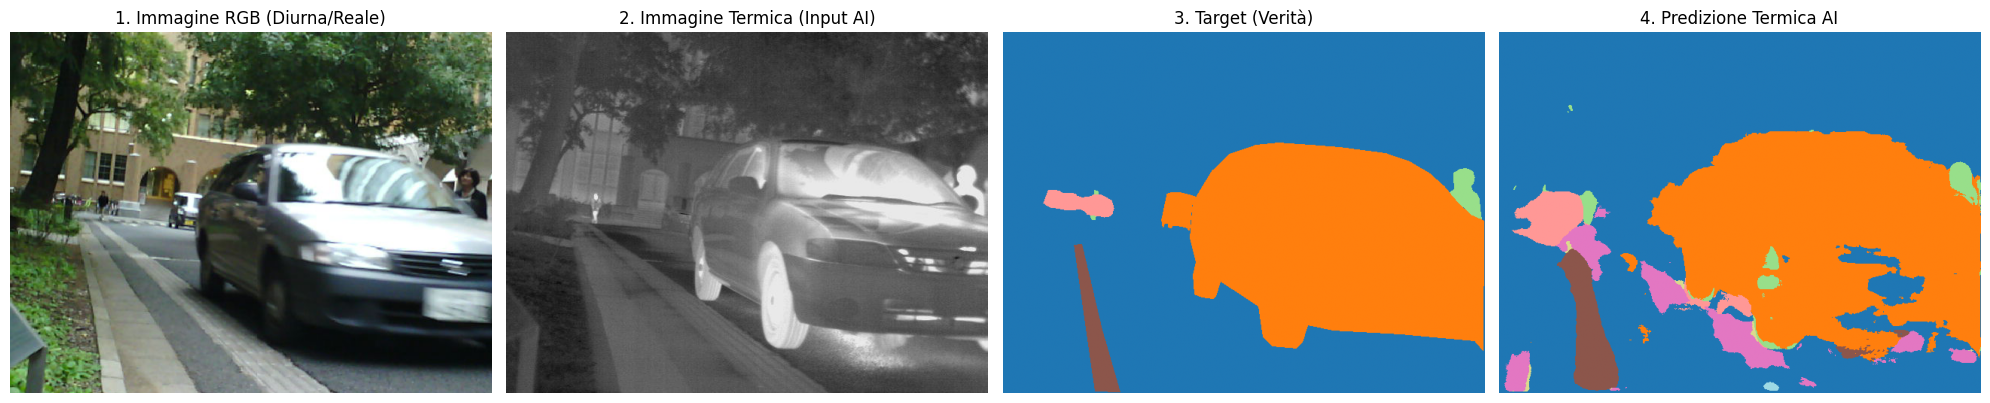

🔍 LEGENDA RAPIDA (Se vedi questi colori nella Predizione):
- Viola/Blu Scuro: Sfondo (Asfalto, Cielo)
- Arancione: Auto (Car)
- Verde Chiaro: Pedone (Person)


In [ ]:
import matplotlib.pyplot as plt
import torch
import random
import numpy as np

# Evaluation Mode
model.eval()

# Pick a random index
random_index = random.randint(0, len(dataset_training) - 1)
img_thermal, img_visual, true_mask = dataset_training[random_index]

# Prepare the input for the model
img_input = img_thermal.unsqueeze(0).to(device)
#img_input = img_visual.unsqueeze(0).to(device)


# Inference
with torch.no_grad():
    output = model(img_input)
    prediction = torch.argmax(output, dim=1).squeeze(0)

img_t_plot = img_thermal.permute(1, 2, 0).cpu().numpy()
img_v_plot = img_visual.permute(1, 2, 0).cpu().numpy()
mask_plot = true_mask.cpu().numpy()
pred_plot = prediction.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# COLUMN 1: RGB image
axes[0].imshow(img_v_plot)
axes[0].set_title("1. RGB Image)")
axes[0].axis('off')

# COLUMN 2: Model input
axes[1].imshow(img_t_plot)
axes[1].set_title("2. Model input")
axes[1].axis('off')

# COLUMN 3: Target
axes[2].imshow(mask_plot, cmap='tab20', vmin=0, vmax=8)
axes[2].set_title("3. Target")
axes[2].axis('off')

# COLUMN 4: Prediction
axes[3].imshow(pred_plot, cmap='tab20', vmin=0, vmax=8)
axes[3].set_title("4. Prediction")
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
"""
In this cell we extract the models from the zip folder
"""

import zipfile
import os

zip_path = "/content/drive/MyDrive/3dPerceptionModels/modelli.zip"
extraction_folder = "/content/extracted_models"

# Create the directory if it doesn't exist
os.makedirs(extraction_folder, exist_ok=True)

print("Extraction in progress...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_folder)

print(f"Extraction completed. Models location: {extraction_folder}")

# Set the paths for the extracted weights
path_weights_rgb = os.path.join(extraction_folder, "best_rgb.pth")
path_weights_ir = os.path.join(extraction_folder, "best_ir.pth")

Estrazione dei modelli in corso...
Modelli estratti con successo in: /content/modelli_estratti


Dataset inizializzato: 1569 immagini a 4 canali trovate.


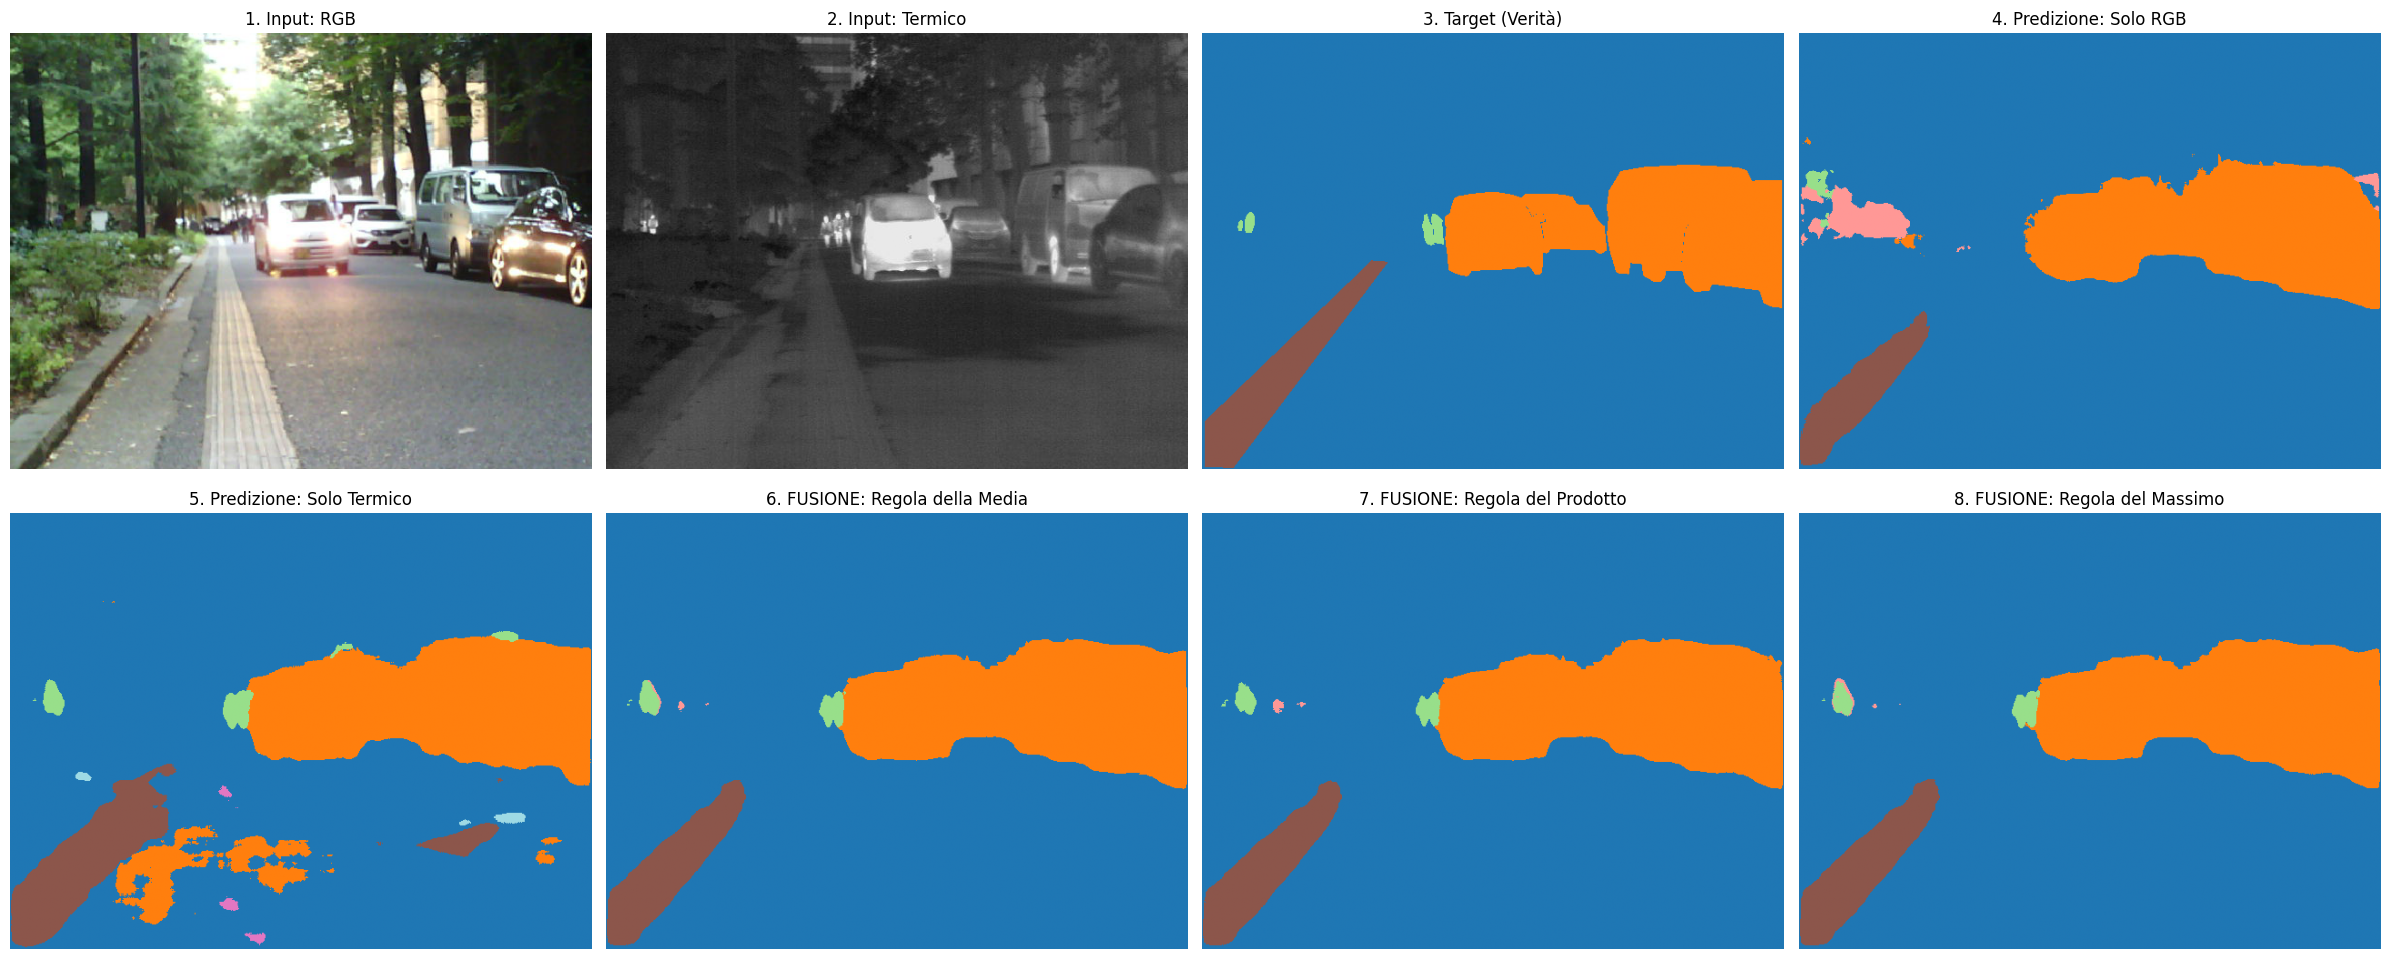

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_rgb = UNet(in_channels=3, num_classes=9).to(device)
model_thermal = UNet(in_channels=3, num_classes=9).to(device)

def clean_state_dict(state_dict):
    """Remove the 'module.' prefix present during training"""
    new_state_dict = {}
    for key, value in state_dict.items():
        new_key = key.replace('module.', '')
        new_state_dict[new_key] = value
    return new_state_dict

state_dict_rgb = torch.load(path_weights_rgb, map_location=device)
state_dict_thermal = torch.load(path_weights_ir, map_location=device)

model_rgb.load_state_dict(clean_state_dict(state_dict_rgb))
model_thermal.load_state_dict(clean_state_dict(state_dict_thermal))

# Set models to inference mode
model_rgb.eval()
model_thermal.eval()

# Preparation and data setup
path_dataset = "/content/MFNet-dataset/ir_seg_dataset"
if not os.path.exists(path_dataset):
    path_dataset = "/content/ir_seg_dataset"

transform = transforms.ToTensor()
dataset_test = MFNetDataset(base_path=path_dataset, transform=transform)

# Let's select a random image
random_index = random.randint(0, len(dataset_test) - 1)
img_thermal, img_visual, true_mask = dataset_test[random_index]

input_thermal = img_thermal.unsqueeze(0).to(device)
input_visual = img_visual.unsqueeze(0).to(device)

with torch.no_grad():
    # Get the raw scores
    logits_thermal = model_thermal(input_thermal)
    logits_rgb = model_rgb(input_visual)

    # Transform Logits into pure probabilities using Softmax
    prob_thermal = F.softmax(logits_thermal, dim=1)
    prob_rgb = F.softmax(logits_rgb, dim=1)

    # FUSION

    # A) Fusing using avarage
    prob_avg = (prob_thermal + prob_rgb) / 2.0

    # B) Fusion usinng product
    prob_product_raw = prob_thermal * prob_rgb
    prob_sum = torch.sum(prob_product_raw, dim=1, keepdim=True)
    prob_product = prob_product_raw / prob_sum

    # C) Fusion using Max
    # torch.max compares the two tensors and takes the highest value for each pixel/class
    prob_max = torch.max(prob_thermal, prob_rgb)

    # Extract predictions
    pred_thermal_argmax = torch.argmax(prob_thermal, dim=1).squeeze(0).cpu().numpy()
    pred_rgb_argmax = torch.argmax(prob_rgb, dim=1).squeeze(0).cpu().numpy()

    pred_avg = torch.argmax(prob_avg, dim=1).squeeze(0).cpu().numpy()
    pred_product = torch.argmax(prob_product, dim=1).squeeze(0).cpu().numpy()
    pred_max = torch.argmax(prob_max, dim=1).squeeze(0).cpu().numpy()

# Draw the entire plot
img_t_plot = img_thermal.permute(1, 2, 0).cpu().numpy()
img_v_plot = img_visual.permute(1, 2, 0).cpu().numpy()
mask_plot = true_mask.cpu().numpy()

# Increase the plot width (from 18 to 24) to fit 4 columns
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

# --- ROW 1: Input, Target, and RGB Prediction ---
axes[0, 0].imshow(img_v_plot)
axes[0, 0].set_title("1. Input: RGB")
axes[0, 0].axis('off')

axes[0, 1].imshow(img_t_plot)
axes[0, 1].set_title("2. Input: Thermal")
axes[0, 1].axis('off')

axes[0, 2].imshow(mask_plot, cmap='tab20', vmin=0, vmax=8)
axes[0, 2].set_title("3. Target (Ground Truth)")
axes[0, 2].axis('off')

axes[0, 3].imshow(pred_rgb_argmax, cmap='tab20', vmin=0, vmax=8)
axes[0, 3].set_title("4. Prediction: RGB Only")
axes[0, 3].axis('off')

# --- ROW 2: Thermal Prediction and the 3 FUSIONS ---
axes[1, 0].imshow(pred_thermal_argmax, cmap='tab20', vmin=0, vmax=8)
axes[1, 0].set_title("5. Prediction: Thermal Only")
axes[1, 0].axis('off')

axes[1, 1].imshow(pred_avg, cmap='tab20', vmin=0, vmax=8)
axes[1, 1].set_title("6. FUSION: Average Rule")
axes[1, 1].axis('off')

axes[1, 2].imshow(pred_product, cmap='tab20', vmin=0, vmax=8)
axes[1, 2].set_title("7. FUSION: Product Rule")
axes[1, 2].axis('off')

axes[1, 3].imshow(pred_max, cmap='tab20', vmin=0, vmax=8)
axes[1, 3].set_title("8. FUSION: Max Rule")
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from torchvision import transforms

path_dataset = "/kaggle/input/datasets/danialqashqai/mfnet-dataset/MFNet-dataset/ir_seg_dataset"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = DualNet(in_channels=3, num_classes=9).to(device)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

# --- IL TOCCO DA MAESTRO: Data Augmentation Indipendente ---
# Aggiungiamo una sfocatura casuale al 30% delle immagini per simulare
# degrado del sensore, nebbia o lenti appannate.
train_transform = transforms.Compose([
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.5, 2.0))], p=0.3),
    transforms.ToTensor()
])

dataset_training = MFNetDataset(base_path=path_dataset, transform=train_transform, mode='train', drop_prob=0.15)
dataloader = DataLoader(dataset_training, batch_size=4, shuffle=True, num_workers=2)

weights = torch.tensor([0.1, 1.5, 2.0, 2.0, 1.0, 1.0, 1.0, 1.5, 1.5]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(model.parameters(), lr=0.0002, weight_decay=1e-5)
scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

epochs = 30
for epoch in range(epochs):
    model.train()
    
    for batch_idx, (img_thermal, img_visual, true_mask) in enumerate(dataloader):
        img_thermal = img_thermal.to(device)
        img_visual = img_visual.to(device)
        true_mask = true_mask.to(device)

        predictions = model(img_visual, img_thermal)
        loss = criterion(predictions, true_mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_idx % 40 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Epoch [{epoch+1}/{epochs}] - Batch {batch_idx} - Loss: {loss.item():.4f} - LR: {current_lr:.6f}")
            
    scheduler.step()

Using device: cuda
Using 2 GPUs!
Dataset initialized: 1569 4-channel images found.
Epoch [1/30] - Batch 0 - Loss: 2.3567 - LR: 0.000200
Epoch [1/30] - Batch 40 - Loss: 1.5917 - LR: 0.000200
Epoch [1/30] - Batch 80 - Loss: 1.9088 - LR: 0.000200
Epoch [1/30] - Batch 120 - Loss: 1.4895 - LR: 0.000200
Epoch [1/30] - Batch 160 - Loss: 1.4268 - LR: 0.000200
Epoch [1/30] - Batch 200 - Loss: 1.6189 - LR: 0.000200
Epoch [1/30] - Batch 240 - Loss: 1.2221 - LR: 0.000200
Epoch [1/30] - Batch 280 - Loss: 1.1664 - LR: 0.000200
Epoch [1/30] - Batch 320 - Loss: 1.0299 - LR: 0.000200
Epoch [1/30] - Batch 360 - Loss: 1.1643 - LR: 0.000200
Epoch [2/30] - Batch 0 - Loss: 1.3466 - LR: 0.000200
Epoch [2/30] - Batch 40 - Loss: 0.7616 - LR: 0.000200
Epoch [2/30] - Batch 80 - Loss: 1.0132 - LR: 0.000200
Epoch [2/30] - Batch 120 - Loss: 1.0891 - LR: 0.000200
Epoch [2/30] - Batch 160 - Loss: 0.9428 - LR: 0.000200
Epoch [2/30] - Batch 200 - Loss: 0.7657 - LR: 0.000200
Epoch [2/30] - Batch 240 - Loss: 1.2680 - LR:

Dataset initialized: 1569 4-channel images found.


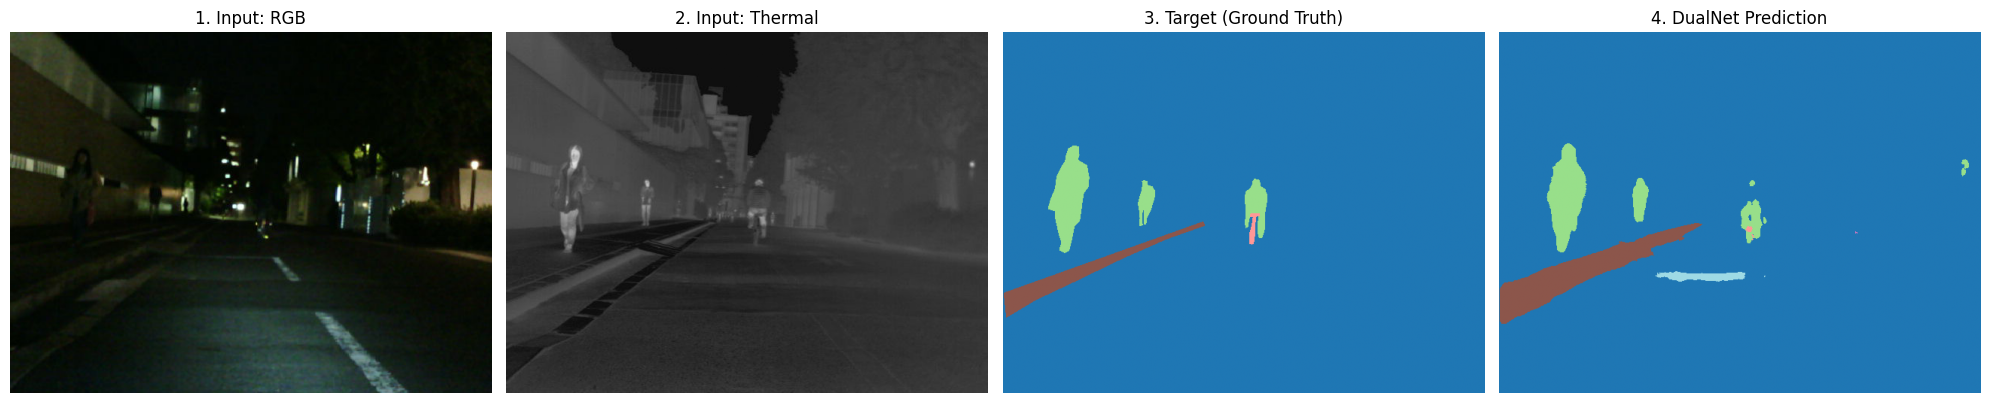

In [13]:
import matplotlib.pyplot as plt
import random
import torch

# 1. Dataset in modalità 'test' (drop_prob=0.0 di default, nessun sensore viene spento)
dataset_test = MFNetDataset(base_path=path_dataset, transform=transform, mode='test')

# 2. Evaluation Mode
model.eval()

# 3. Pick a random index
random_index = random.randint(0, len(dataset_test) - 1)
img_thermal, img_visual, true_mask = dataset_test[random_index]

# 4. Prepare inputs (add batch dimension and move to GPU)
input_thermal = img_thermal.unsqueeze(0).to(device)
input_visual = img_visual.unsqueeze(0).to(device)

# 5. Inference
with torch.no_grad():
    # IL DOPPIO INPUT: passiamo entrambi i tensori al modello
    output = model(input_visual, input_thermal)
    prediction = torch.argmax(output, dim=1).squeeze(0)

# 6. Prepare images for Matplotlib
img_t_plot = img_thermal.permute(1, 2, 0).cpu().numpy()
img_v_plot = img_visual.permute(1, 2, 0).cpu().numpy()
mask_plot = true_mask.cpu().numpy()
pred_plot = prediction.cpu().numpy()

# --- 7. DRAW THE 4-COLUMN COMPARISON ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_v_plot)
axes[0].set_title("1. Input: RGB")
axes[0].axis('off')

axes[1].imshow(img_t_plot)
axes[1].set_title("2. Input: Thermal")
axes[1].axis('off')

axes[2].imshow(mask_plot, cmap='tab20', vmin=0, vmax=8)
axes[2].set_title("3. Target (Ground Truth)")
axes[2].axis('off')

axes[3].imshow(pred_plot, cmap='tab20', vmin=0, vmax=8)
axes[3].set_title("4. DualNet Prediction")
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [10]:
# --- DA METTERE ALLA FINE DI TUTTO (fuori dal ciclo for delle epoche) ---

percorso_salvataggio = "dualnet_sota_weights.pth"

# Se il modello è avvolto in DataParallel (più GPU), salviamo il modulo interno pulito
if isinstance(model, nn.DataParallel):
    torch.save(model.module.state_dict(), percorso_salvataggio)
else:
    # Se stiamo usando una sola GPU o CPU
    torch.save(model.state_dict(), percorso_salvataggio)

print(f"Addestramento terminato! Capolavoro salvato in: {percorso_salvataggio}")

Addestramento terminato! Capolavoro salvato in: dualnet_sota_weights.pth
